In [1]:
import graphcast.data_utils as gc_du
import graphcast.solar_radiation as gc_sr

In [ ]:
from collections.abc import Callable, Sequence
import dataclasses
import functools

import chex
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import xarray as xa
import solar_radiation_deprecated_not_working as sr

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.pyplot as plt

In [48]:
import xarray as xr
dsera5 = xr.open_dataset('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_era5_1980_2022_6h-128x64_equiangular_with_poles_conservative/fields.zarr').isel(time=slice(int(10*365.5*4)+28, int(10*365.25*4 + 365*4)+34))
# Lat-lon
era5_grid_lat_vals = np.array(
    dsera5["latitude"], dtype=np.float32
)  # (num_lat,)
era5_grid_lon_vals = np.array(
    dsera5["longitude"], dtype=np.float32
)  # (num_long,)
era5_num_lat = era5_grid_lat_vals.shape[0]
era5_num_lon = era5_grid_lon_vals.shape[0]

# Construct timestamps
# Time 0 here is 1959-01-01, 00:00
print("Constructing timestamps")
era5_time_vals = dsera5.coords["time"].values



Constructing timestamps


In [ ]:
era5_toa_array = sr.get_toa_incident_solar_radiation(
    era5_time_vals,
    era5_grid_lat_vals,
    era5_grid_lon_vals,
)  # (num_time, num_lat, num_lon)
# Normalize to [0,1]
era5_toa_min = era5_toa_array.min()
era5_toa_max = era5_toa_array.max()
era5_toa_array_normalized = (era5_toa_array - era5_toa_min) / (era5_toa_max - era5_toa_min)
era5_toa_array_normalized_transposed = era5_toa_array_normalized.transpose(0, 2, 1)

In [3]:
import cftime
fields_group_path = f'/hkfs/work/workspace/scratch/xo8179-ukesm/global_1990_2019_equiangular_wp_conservative/fields.zarr'
fields_group_long = xa.open_zarr(fields_group_path)
fields_group = fields_group_long.isel(time=slice(0,360*4))

# Lat-lon
grid_lat_vals = np.array(
    fields_group["latitude"], dtype=np.float32
)  # (num_lat,)
grid_lon_vals = np.array(
    fields_group["longitude"], dtype=np.float32
)  # (num_long,)
num_lat = grid_lat_vals.shape[0]
num_lon = grid_lon_vals.shape[0]

# Construct timestamps
# Time 0 here is 1959-01-01, 00:00
print("Constructing timestamps")
time_vals = fields_group.coords["time"].values

# Handle CFTime vs datetime64 calendars
if np.issubdtype(time_vals.dtype, np.datetime64):
    # Regular datetime64 (ERA5-style)
    timestamps = time_vals.astype("datetime64[s]")
    seconds_since_epoch = timestamps.astype("int64")
    timestamps_for_graphcast = time_vals.astype("datetime64[ns]")
else:
    # CFTime (360-day or other non-Gregorian calendars)
    timestamps = time_vals  # keep as cftime.Datetime360Day objects
    
    # CFTime → approximate datetime64 (drop calendar info)
    dt_seconds = (time_vals[1] - time_vals[0]).total_seconds()
    freq_hours = int(round(dt_seconds / 3600))
    
    # Create a continuous datetime64 series with same number of steps
    timestamps_for_graphcast = pd.date_range(
        start="1990-01-01 00:00:00",
        periods=len(time_vals),
        freq=f"{freq_hours}H"
    )

    # Convert to numeric seconds manually
    epoch = cftime.Datetime360Day(1959, 1, 1, 0, 0, 0)
    seconds_since_epoch = np.array([
        (t - epoch).total_seconds() for t in timestamps
    ], dtype=np.float64)



num_time = seconds_since_epoch.shape[0]

# Create zarr to save to
forcing_field_shape = (num_time, num_lon, num_lat)
forcing_fields_dict = {}



Constructing timestamps


/scratch/ipykernel_2480073/3162247590.py:36: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  timestamps_for_graphcast = pd.date_range(


In [4]:
# TOA radiation
print("Generating TOA radiation")
toa_array = gc_sr.get_toa_incident_solar_radiation(
    timestamps_for_graphcast,
    grid_lat_vals,
    grid_lon_vals,
)  # (num_time, num_lat, num_lon)
# Normalize to [0,1]
toa_min = toa_array.min()
toa_max = toa_array.max()
toa_array_normalized = (toa_array - toa_min) / (toa_max - toa_min)
toa_array_normalized_transposed = toa_array_normalized.transpose(0, 2, 1)

Generating TOA radiation


Text(0.5, 1.0, 'Time: 1990-12-30 18:00:00')

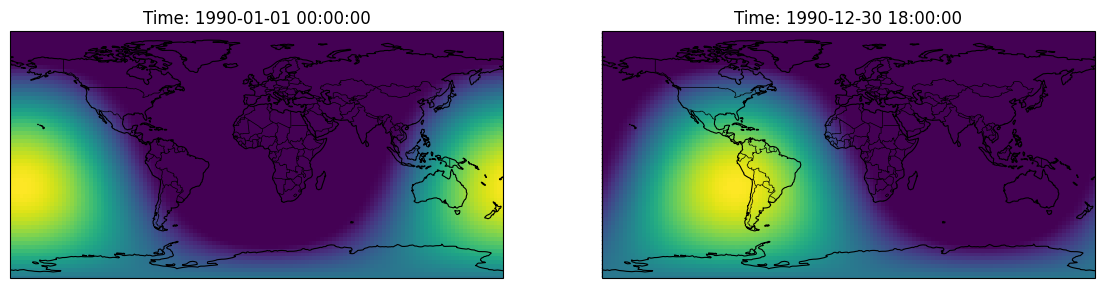

In [7]:
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), subplot_kw={"projection": proj}
)


im = axes[0].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[0].T,
    transform=proj,
    cmap='viridis'
)
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[0].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[0].set_title(f'Time: {timestamps[0]}')

im = axes[1].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[-1].T,
    transform=proj,
    cmap='viridis'
)
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[1].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[1].set_title(f'Time: {timestamps[-1]}')

In [46]:
def _get_j2000_days(timestamp) -> float:
    if isinstance(timestamp, (np.datetime64, pd.Timestamp)):
        return pd.Timestamp(timestamp).to_julian_date() - gc_sr._J2000_EPOCH

    elif "cftime" in type(timestamp).__module__:
        # Handle cftime.Datetime360Day or similar
        # Convert to fractional year, then approximate J2000 offset
        year_start = type(timestamp)(timestamp.year, 1, 1)
        day_of_year = (timestamp - year_start).days
        fractional_year = timestamp.year + day_of_year / 360.0
        # Convert fractional year to days since J2000 epoch (approx)

        day = int((fractional_year - 2000.0) * 365.25)

        day += (
            (timestamp.hour - 12) / 24.0
            + timestamp.minute / 1440.0
            + timestamp.second / 86400.0
        )
        return day  # same scaling as Julian years

    else:
        raise TypeError(f"Unsupported timestamp type: {type(timestamp)}")

In [51]:
id=-1
print(f'Converted: {timestamps[id]}: {_get_j2000_days(timestamps[id])}')
print(f'{era5_time_vals[id]}: {_get_j2000_days(era5_time_vals[id])}')

Converted: 1990-12-30 18:00:00: -3287.75
1990-12-30T18:00:00.000000000: -3288.75


In [6]:
import solar_radiation_stable as sr2
toa_array = sr2.get_toa_incident_solar_radiation(
    timestamps,
    grid_lat_vals,
    grid_lon_vals,
    integration_period='6h'
)  # (num_time, num_lat, num_lon)
# Normalize to [0,1]
toa_min = toa_array.min()
toa_max = toa_array.max()
toa_array_normalized = (toa_array - toa_min) / (toa_max - toa_min)
toa_array_normalized_transposed = toa_array_normalized.transpose(0, 2, 1)

Text(0.5, 1.0, 'Time: 1990-12-30 18:00:00')

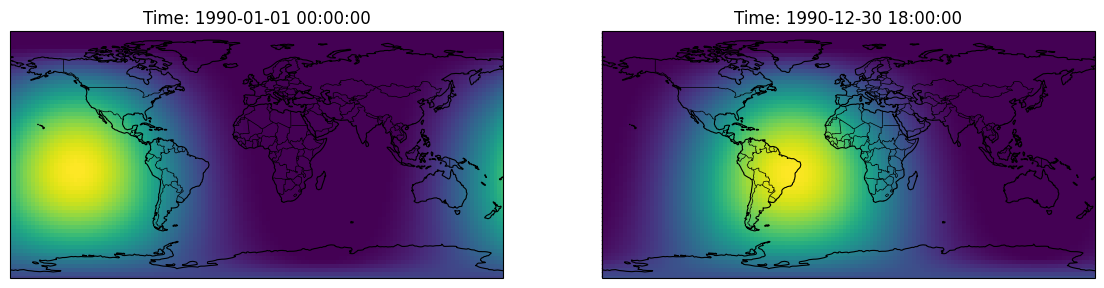

In [9]:
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), subplot_kw={"projection": proj}
)


im = axes[0].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[0].T,
    transform=proj,
    cmap='viridis'
)
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[0].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[0].set_title(f'Time: {timestamps[0]}')

im = axes[1].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[-1].T,
    transform=proj,
    cmap='viridis'
)
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[1].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[1].set_title(f'Time: {timestamps[-1]}')

In [ ]:

toa_array = sr.get_toa_incident_solar_radiation(
    timestamps_for_graphcast,
    grid_lat_vals,
    grid_lon_vals,
)  # (num_time, num_lat, num_lon)
# Normalize to [0,1]
toa_min = toa_array.min()
toa_max = toa_array.max()
toa_array_normalized = (toa_array - toa_min) / (toa_max - toa_min)
toa_array_normalized_transposed = toa_array_normalized.transpose(0, 2, 1)

In [ ]:

print(toa_array[0].shape)

(64, 128)


Text(0.5, 1.0, 'Time: 1990-10-01 00:00:00')

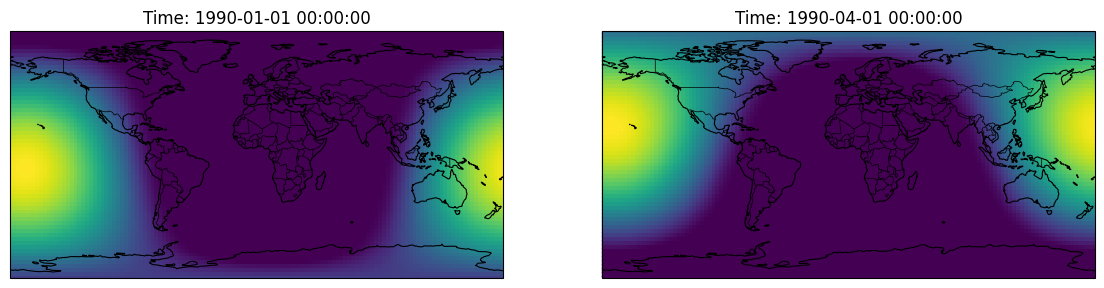

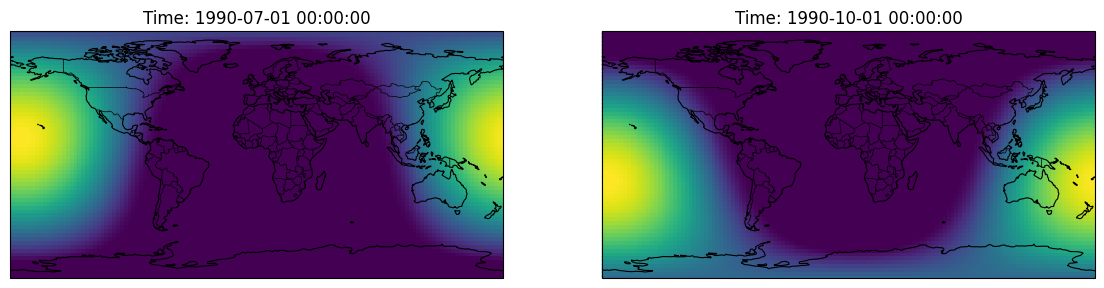

In [ ]:

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), subplot_kw={"projection": proj}
)


im = axes[0].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[0].T,
    transform=proj,
    cmap='viridis'
)
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[0].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[0].set_title(f'Time: {timestamps[0]}')

im = axes[1].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[int(1440/4)].T,
    transform=proj,
    cmap='viridis'
)
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[1].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[1].set_title(f'Time: {timestamps[int(1440/4)]}')

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), subplot_kw={"projection": proj}
)


im = axes[0].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[int(1440/2)].T,
    transform=proj,
    cmap='viridis'
)
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[0].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[0].set_title(f'Time: {timestamps[int(1440/2)]}')

im = axes[1].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[int(1440/2 + 1440/4)].T,
    transform=proj,
    cmap='viridis'
)
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[1].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[1].set_title(f'Time: {timestamps[int(1440/2 + 1440/4)]}')

Text(0.5, 1.0, 'Time: 1990-01-01 18:00:00')

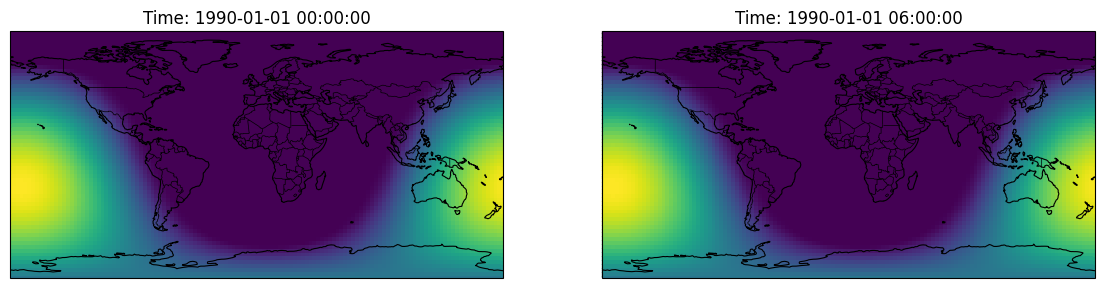

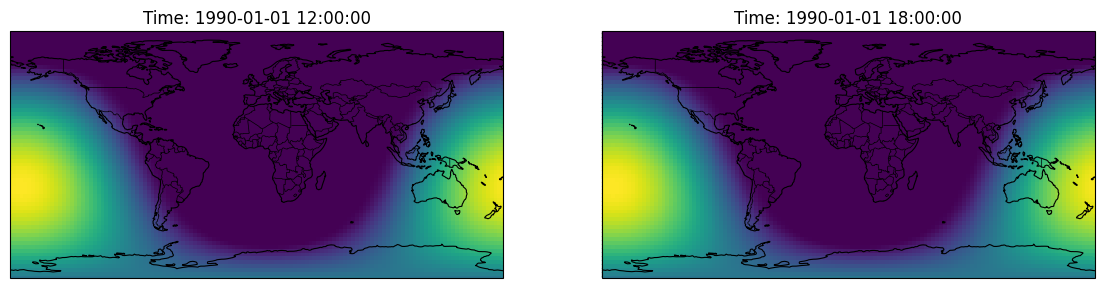

In [45]:
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), subplot_kw={"projection": proj}
)


im = axes[0].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[0].T,
    transform=proj,
    cmap='viridis'
)
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[0].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[0].set_title(f'Time: {timestamps[0]}')

im = axes[1].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[1].T,
    transform=proj,
    cmap='viridis'
)
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[1].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[1].set_title(f'Time: {timestamps[1]}')

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), subplot_kw={"projection": proj}
)


im = axes[0].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[2].T,
    transform=proj,
    cmap='viridis'
)
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[0].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[0].set_title(f'Time: {timestamps[2]}')

im = axes[1].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[3].T,
    transform=proj,
    cmap='viridis'
)
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[1].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[1].set_title(f'Time: {timestamps[3]}')

Text(0.5, 1.0, 'Time: 1990-12-30 18:00:00')

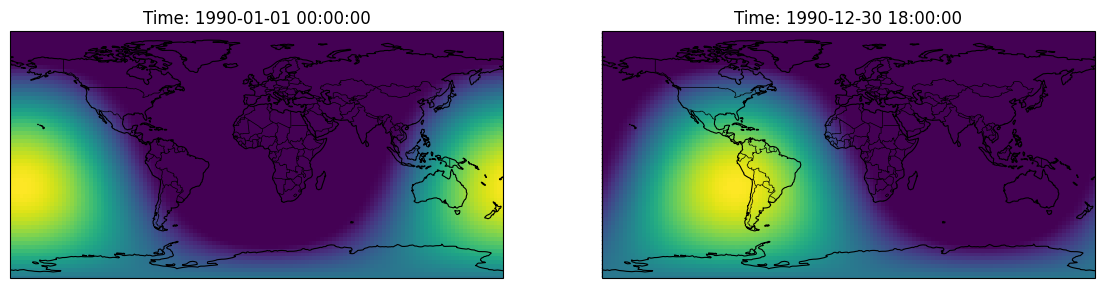

In [18]:
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), subplot_kw={"projection": proj}
)


im = axes[0].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[0].T,
    transform=proj,
    cmap='viridis'
)
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[0].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[0].set_title(f'Time: {timestamps[0]}')

im = axes[1].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[-1].T,
    transform=proj,
    cmap='viridis'
)
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[1].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[1].set_title(f'Time: {timestamps[-1]}')

Text(0.5, 1.0, 'Time: 1990-01-01 18:00:00')

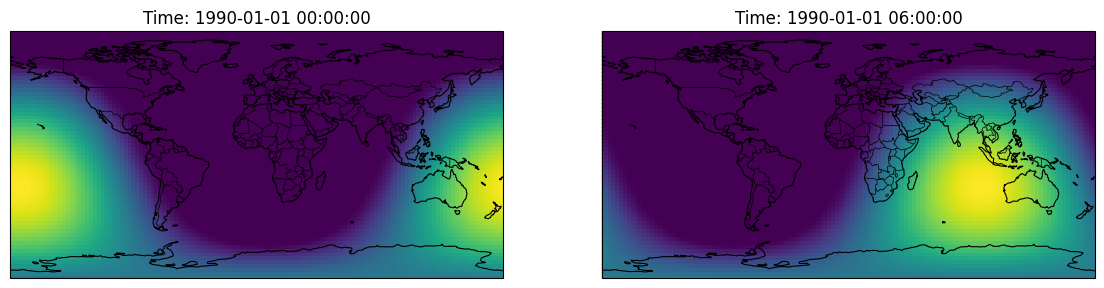

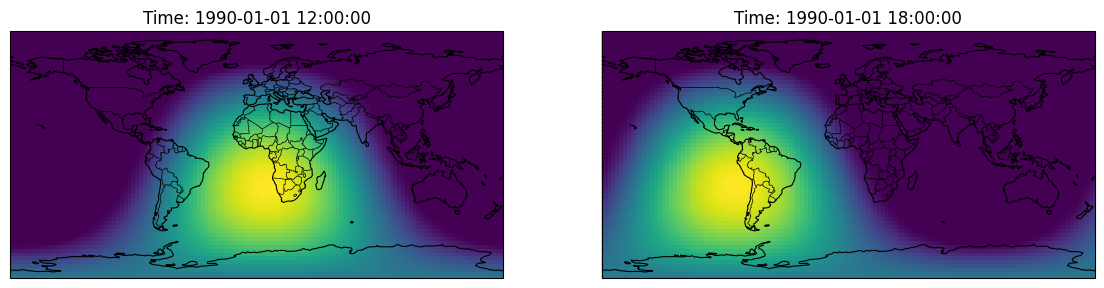

In [46]:
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), subplot_kw={"projection": proj}
)


im = axes[0].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[0].T,
    transform=proj,
    cmap='viridis'
)
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[0].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[0].set_title(f'Time: {timestamps[0]}')

im = axes[1].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[1].T,
    transform=proj,
    cmap='viridis'
)
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[1].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[1].set_title(f'Time: {timestamps[1]}')

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), subplot_kw={"projection": proj}
)


im = axes[0].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[2].T,
    transform=proj,
    cmap='viridis'
)
axes[0].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[0].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[0].set_title(f'Time: {timestamps[2]}')

im = axes[1].pcolormesh(
    grid_lon_vals, grid_lat_vals, toa_array_normalized_transposed[3].T,
    transform=proj,
    cmap='viridis'
)
axes[1].add_feature(cfeature.COASTLINE, linewidth=0.8)
axes[1].add_feature(cfeature.BORDERS, linewidth=0.5)
axes[1].set_title(f'Time: {timestamps[3]}')